## Load Data
Analyze an e-commerce orders dataset to understand patterns, trends, and distributions in sales, fulfillment, and customer behavior.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:


df = pd.read_excel(r"C:\Users\user\Downloads\Dataset for Data Analytics (1).xlsx")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


## Basic Statistics

Calculate summary statistics — mean, median, and count — for the numeric fields, and value counts for the categorical fields, to understand the overall shape of the data before digging into trends.


In [4]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
df[numeric_cols].agg(["mean", "median", "count"])

,Quantity,UnitPrice,ItemsInCart,TotalPrice
mean,2.945833,356.41275,5.485,1053.9683
median,3.000000,364.21000,5.000,823.6150
count,1200.000000,1200.00000,1200.000,1200.0000


In [5]:
df["Product"].value_counts()
df["OrderStatus"].value_counts()
df["PaymentMethod"].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

> **Observation:** Average order value is ₦1,053.97 vs. median ₦823.62 — right-skewed, pulled up by bulk orders. Product demand is fairly even across all 7 products.

## Revenue Trend
Group orders by month to see how revenue changes over time.

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='Month'>

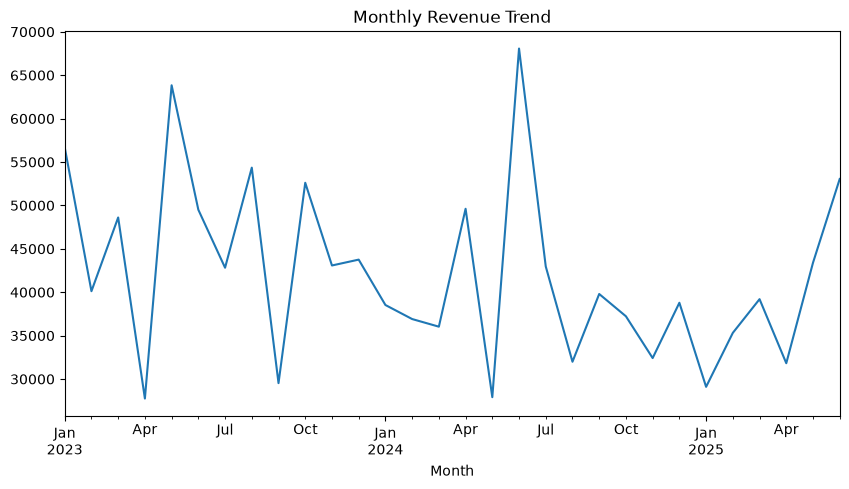

In [6]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["TotalPrice"].sum()
monthly_revenue.plot(kind="line", title="Monthly Revenue Trend", figsize=(10,5))

> **Observation:** Revenue swings between ₦27,752–₦68,069/month with no sustained trend — flat rather than growing.

## Outliers
Use the IQR method on TotalPrice to flag unusually large orders.

8 outlier orders out of 1200


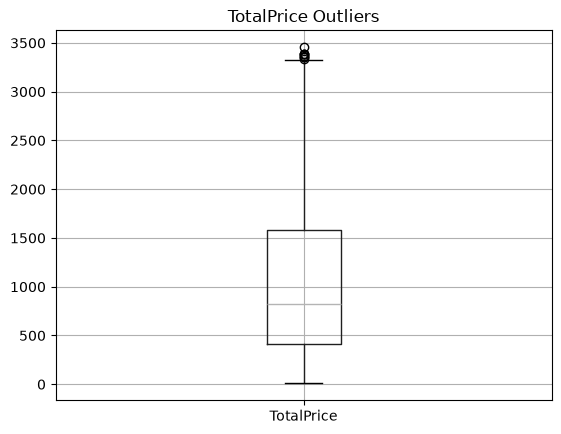

In [7]:


Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

outliers = df[(df["TotalPrice"] < lower) | (df["TotalPrice"] > upper)]
print(f"{len(outliers)} outlier orders out of {len(df)}")

# Visual check

df.boxplot(column="TotalPrice")
plt.title("TotalPrice Outliers")
plt.show()

> **Observation:** 8 orders exceed the upper bound, all legitimate bulk purchases (Quantity=5) — no cleaning needed.

## Order Status Over Time
Check whether Cancelled, Returned, Pending, Shipped, and Delivered orders shift over the period, or stay steady.

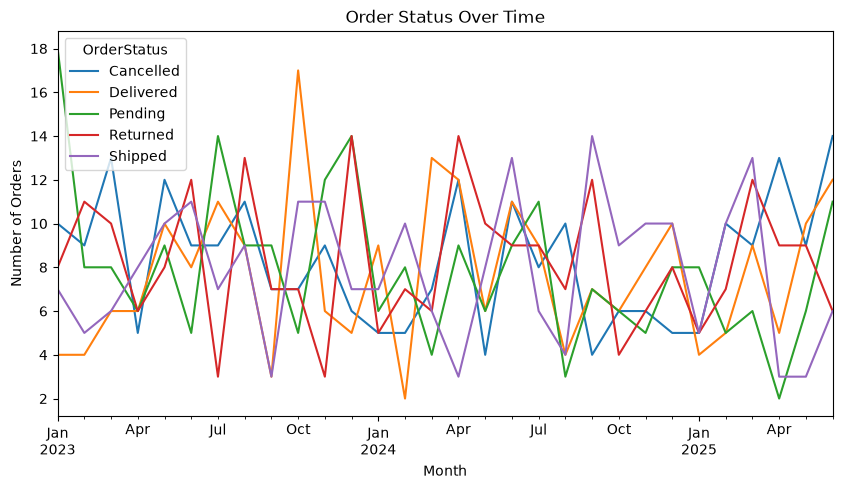

In [8]:
status_trend = df.groupby(["Month", "OrderStatus"]).size().unstack(fill_value=0)
status_trend.plot(kind="line", figsize=(10,5), title="Order Status Over Time")
plt.ylabel("Number of Orders")
plt.show()

> **Observation:** Order status mix stays fairly steady month to month — Cancelled, Returned, and Pending each track close to Delivered, with no single status trending up or down over time.

In [9]:
for col in ["UnitPrice", "Quantity"]:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {n_out} outliers (bounds {lower:.2f} to {upper:.2f})")

UnitPrice: 0 outliers (bounds -317.20 to 1024.83)
Quantity: 0 outliers (bounds -1.00 to 7.00)


> **Observation:** No outliers found in UnitPrice or Quantity individually — 
> the TotalPrice outliers come from the combination of high quantity and 
> price, not from either field being extreme on its own.

In [10]:
df["UsedCoupon"] = df["CouponCode"].notna()
df.groupby("UsedCoupon")["TotalPrice"].mean()

UsedCoupon
False    1043.370259
True     1057.643715
Name: TotalPrice, dtype: float64

> **Observation:** Coupon usage has little effect on order value — orders 
> with a coupon (₦1,057.64 avg) and without (₦1,043.37 avg) are nearly 
> identical, a difference of about 1%.

### Sales and Pricing
- Average order value is ₦1,053.97, but median is ₦823.62 — right-skewed, pulled up by bulk orders.
- Product demand is fairly even: Printer (181), Tablet (179), Chair (178), Laptop (173), Desk (170), Monitor (163), Phone (156).

### Revenue Trend
- Monthly revenue fluctuates between ₦27,752–₦68,069 with no sustained trend.
- June 2024 was strongest; April 2023 was weakest — no obvious seasonality.

### Order Fulfillment
- Only ~19% of orders reach "Delivered." Cancelled (250), Returned (247), Pending (237), Shipped (235) are each nearly as common.
- Cancellations spread evenly across products (31–45 each).

### Outliers
- 8 orders exceed the upper IQR bound on TotalPrice, all legitimate bulk purchases — no cleaning needed.

### Coupons and Channels
- FREESHIP is the most-used coupon (313 orders); ~26% used none.
- Instagram (259) and Email (250) are the top referral sources.